In [15]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/content/drive/MyDrive/car_insurance.csv")



In [16]:
print("\n=== HEAD ===")
print(df.head())

print("\n=== INFO ===")
print(df.info())

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe(include="all"))


=== HEAD ===
       id  age  gender driving_experience    education         income  \
0  569520    3       0               0-9y  high school    upper class   
1  750365    0       1               0-9y         none        poverty   
2  199901    0       0               0-9y  high school  working class   
3  478866    0       1               0-9y   university  working class   
4  731664    1       1             10-19y         none  working class   

   credit_score  vehicle_ownership vehicle_year  married  children  \
0      0.629027                1.0   after 2015      0.0       1.0   
1      0.357757                0.0  before 2015      0.0       0.0   
2      0.493146                1.0  before 2015      0.0       0.0   
3      0.206013                1.0  before 2015      0.0       1.0   
4      0.388366                1.0  before 2015      0.0       0.0   

   postal_code  annual_mileage vehicle_type  speeding_violations  duis  \
0        10238         12000.0        sedan         

In [17]:
print("\n=== MISSING VALUES PER COLUMN ===")
print(df.isna().sum())


=== MISSING VALUES PER COLUMN ===
id                       0
age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64


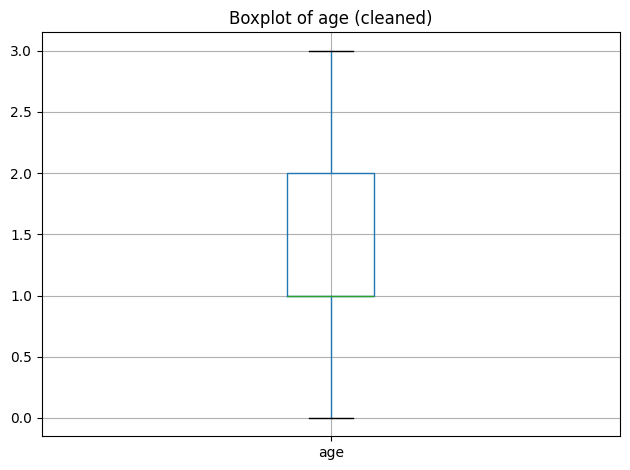

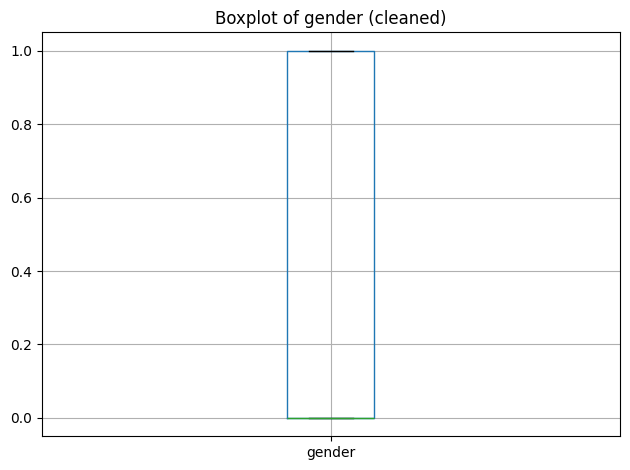

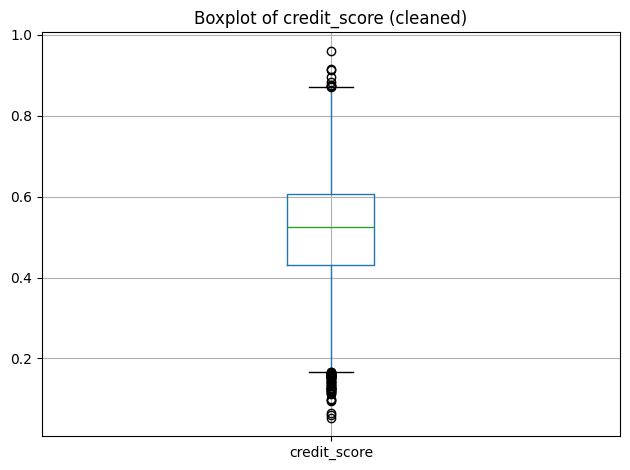

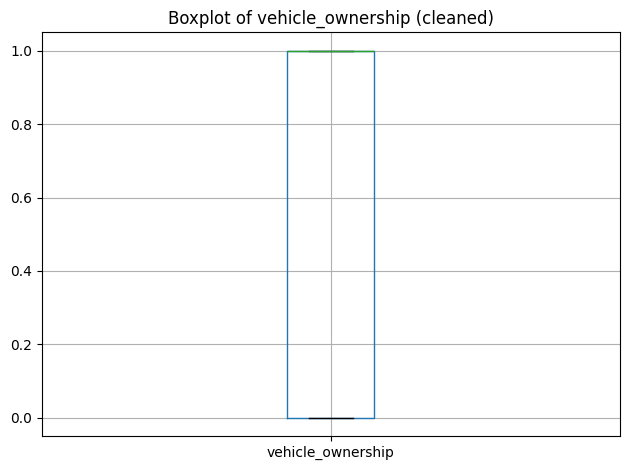

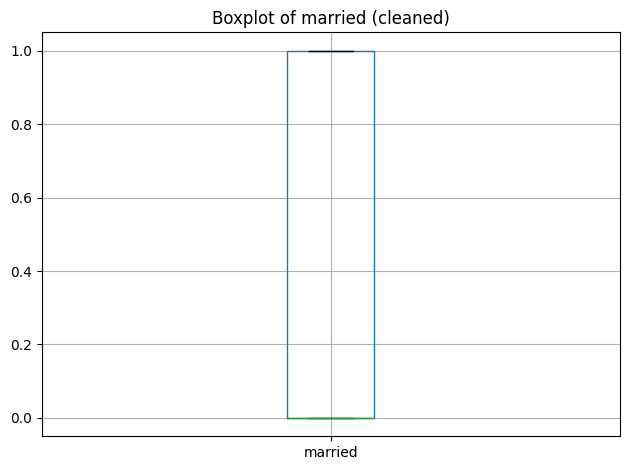

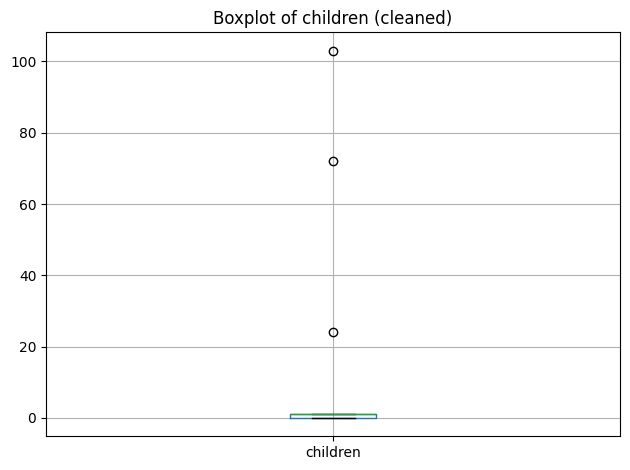

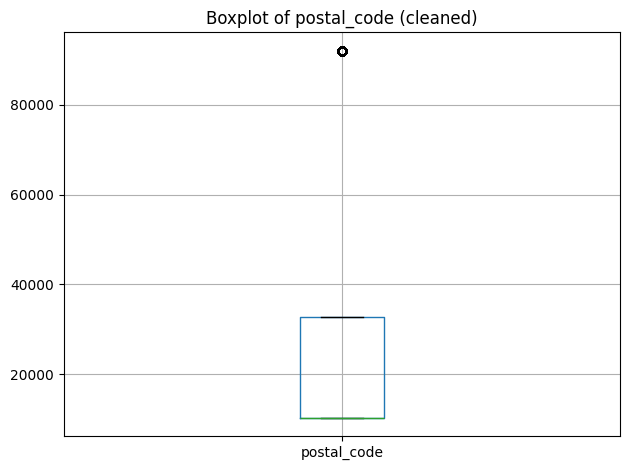

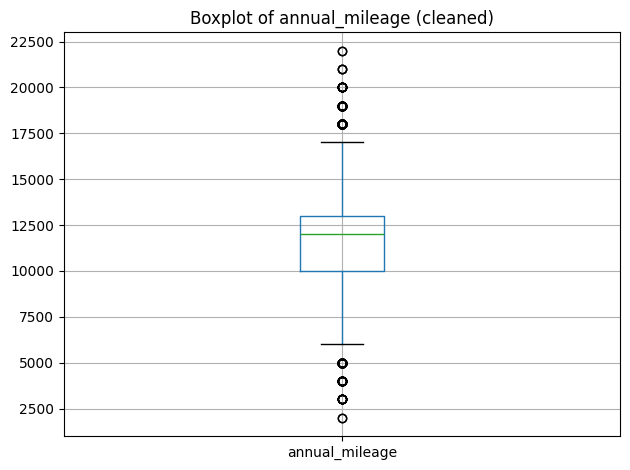

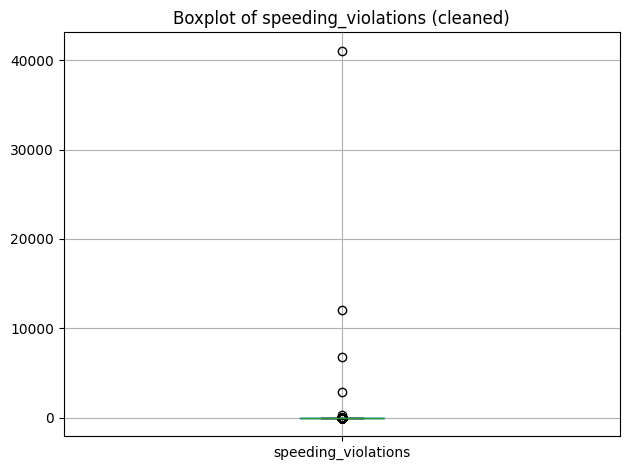

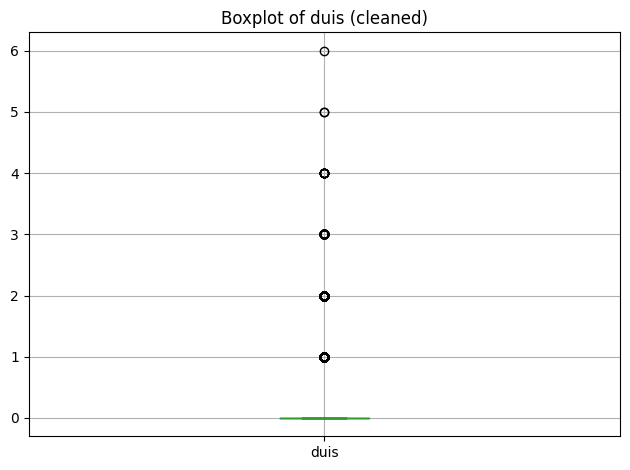

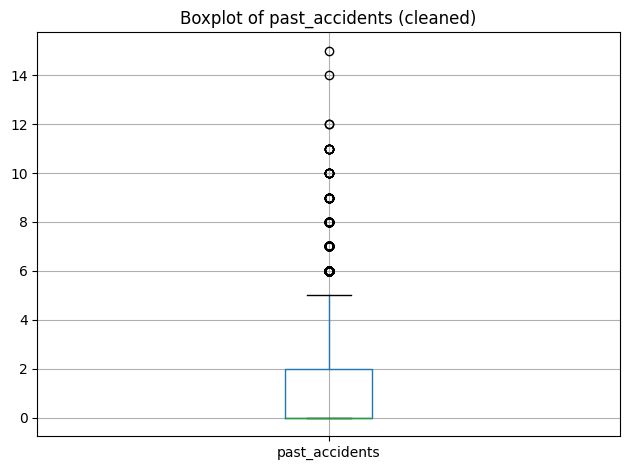

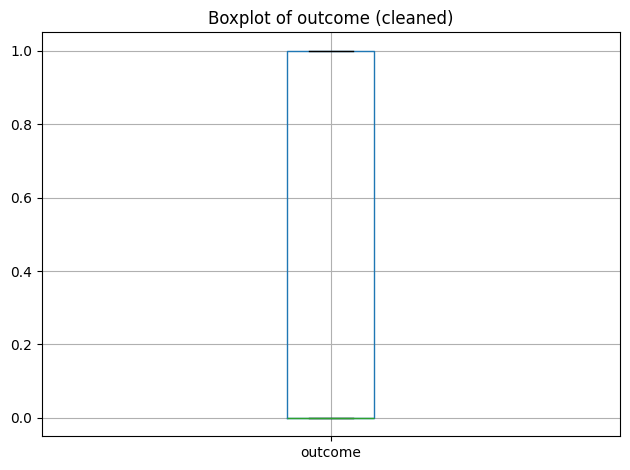

In [29]:
for col in num_cols:
    plt.figure()
    df.boxplot(column=[col])
    plt.title(f"Boxplot of {col} (cleaned)")
    plt.tight_layout()
    plt.show()


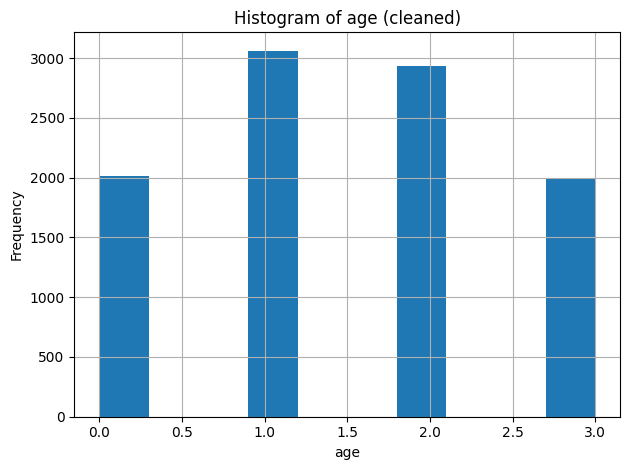

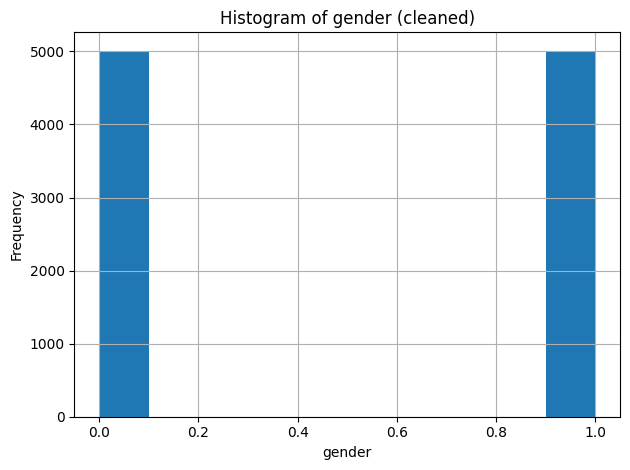

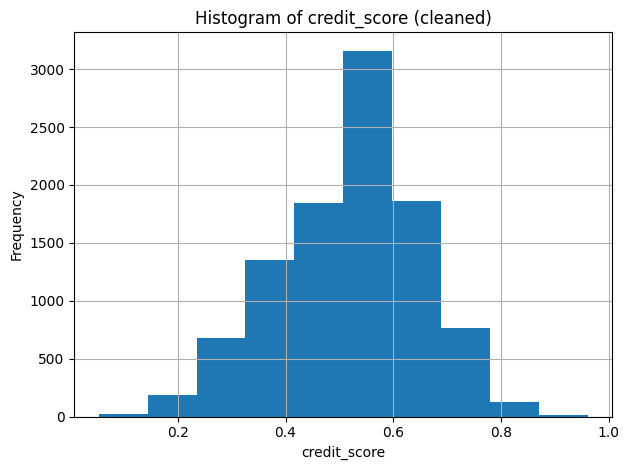

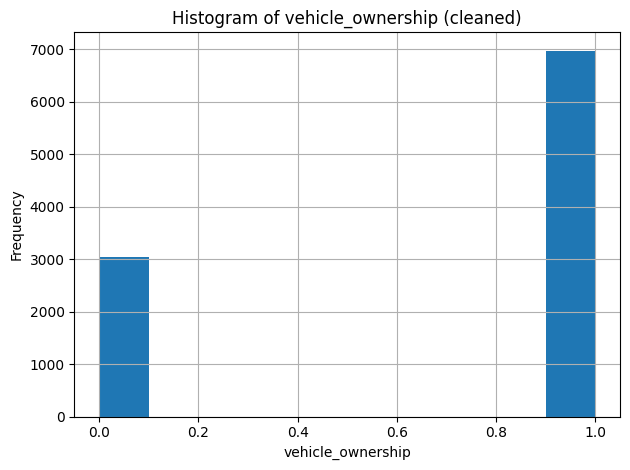

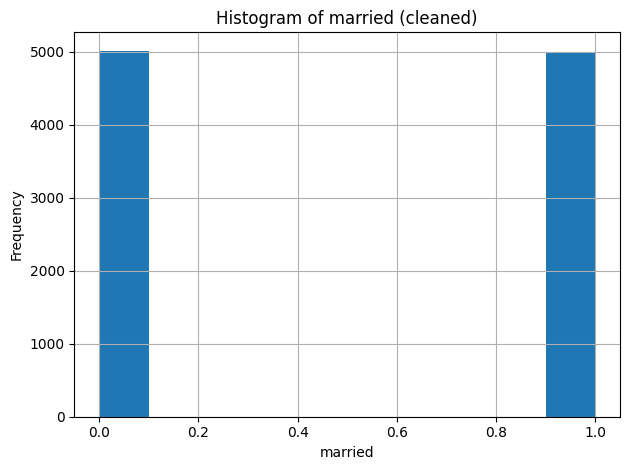

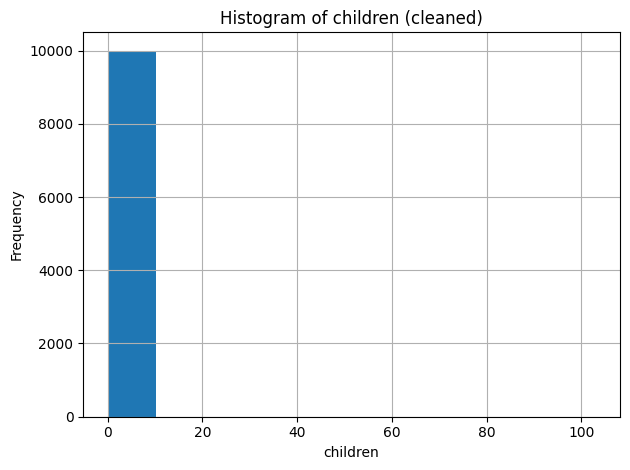

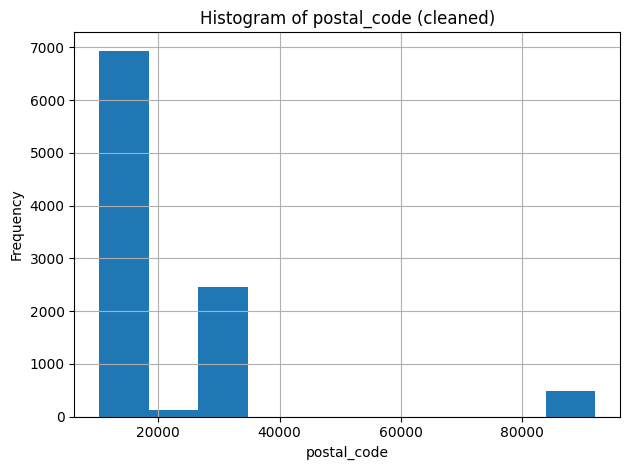

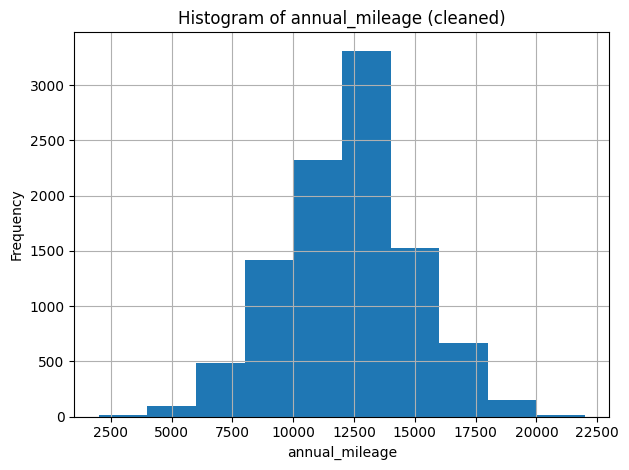

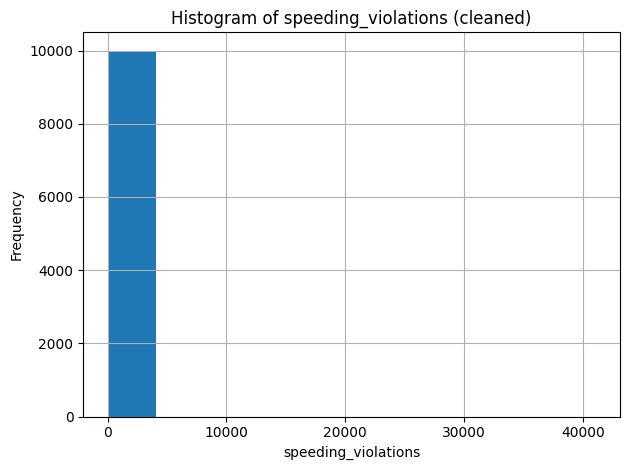

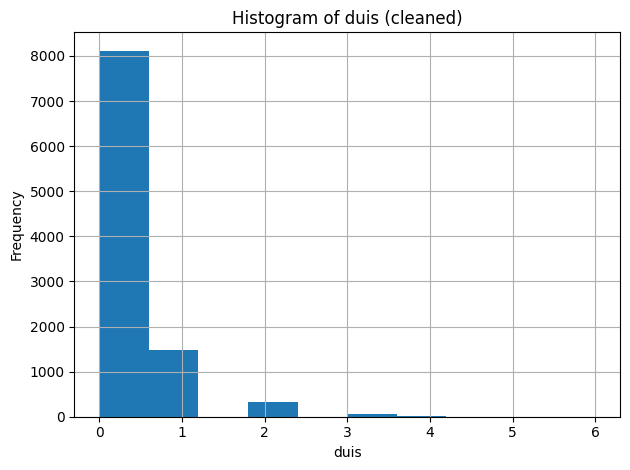

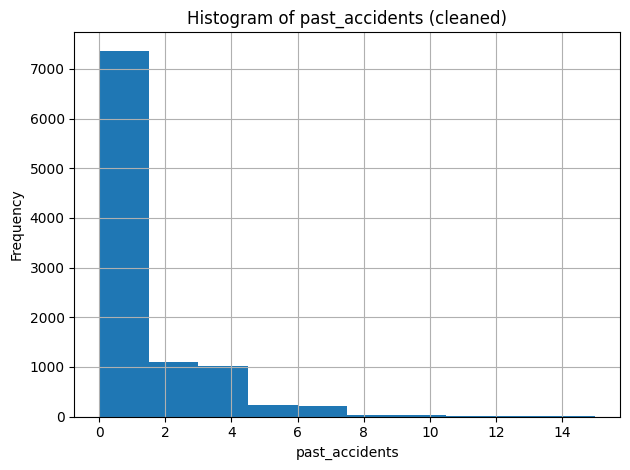

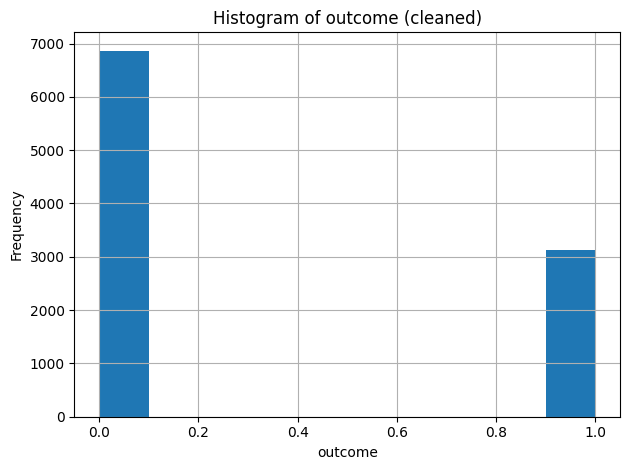

In [28]:
for col in num_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Histogram of {col} (cleaned)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [18]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("\n=== NUMERICAL COLUMNS ===")
print(list(num_cols))



=== NUMERICAL COLUMNS ===
['id', 'age', 'gender', 'credit_score', 'vehicle_ownership', 'married', 'children', 'postal_code', 'annual_mileage', 'speeding_violations', 'duis', 'past_accidents', 'outcome']


In [20]:
threshold = len(df) / 3
cols_to_drop = missing_count[missing_count > threshold].index
df = df.drop(columns=cols_to_drop)
print("\nDropped columns due to excessive NA:", list(cols_to_drop))



Dropped columns due to excessive NA: []


In [21]:
useless_cols = ["id"] if "id" in df.columns else []
df = df.drop(columns=useless_cols)
print("\nRemoved useless columns:", useless_cols)


Removed useless columns: ['id']


In [22]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("\nNumerical variables:", list(num_cols))
print("Categorical variables:", list(cat_cols))


Numerical variables: ['age', 'gender', 'credit_score', 'vehicle_ownership', 'married', 'children', 'postal_code', 'annual_mileage', 'speeding_violations', 'duis', 'past_accidents', 'outcome']
Categorical variables: ['driving_experience', 'education', 'income', 'vehicle_year', 'vehicle_type']


In [23]:
for col in num_cols:
    if df[col].isna().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

In [24]:
for col in cat_cols:
    if df[col].isna().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)


In [25]:
print("\nRemaining missing values:\n", df.isna().sum())


Remaining missing values:
 age                    0
gender                 0
driving_experience     0
education              0
income                 0
credit_score           0
vehicle_ownership      0
vehicle_year           0
married                0
children               0
postal_code            0
annual_mileage         0
vehicle_type           0
speeding_violations    0
duis                   0
past_accidents         0
outcome                0
dtype: int64


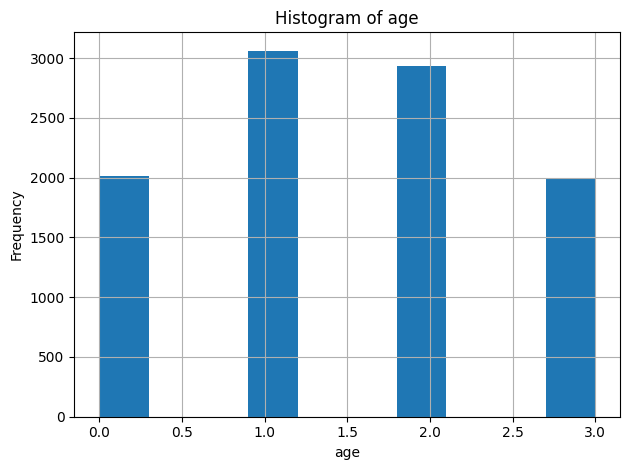

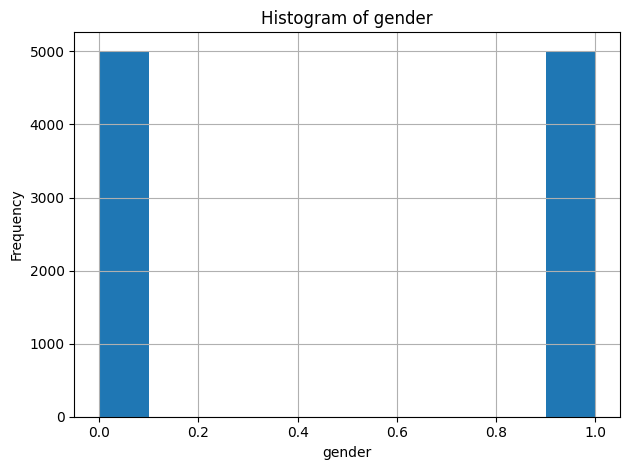

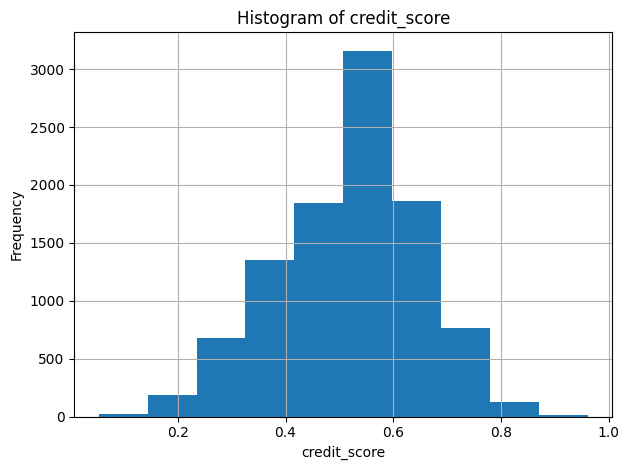

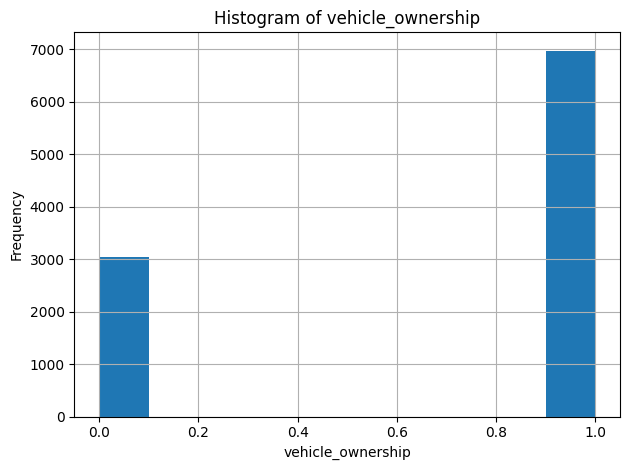

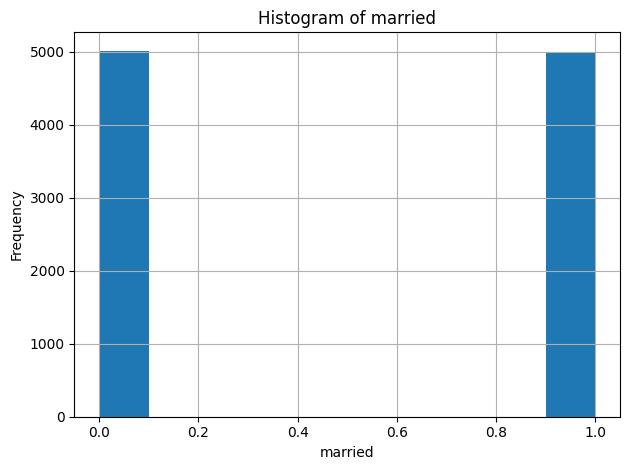

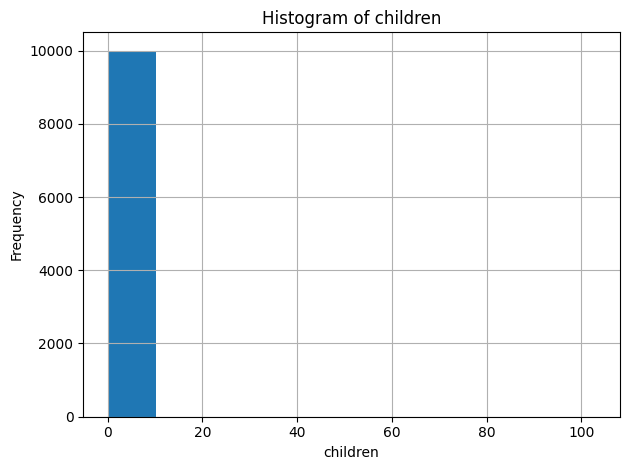

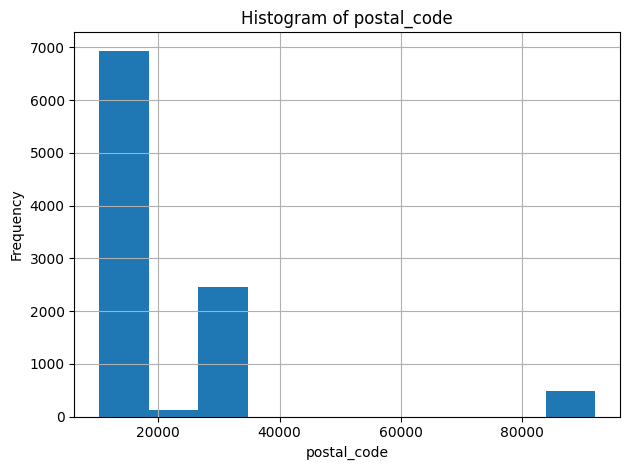

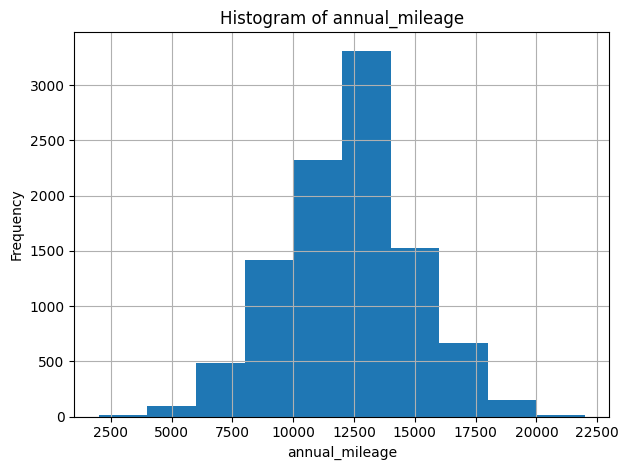

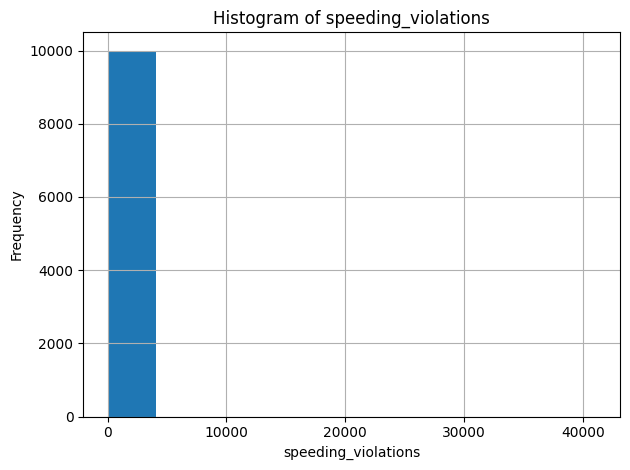

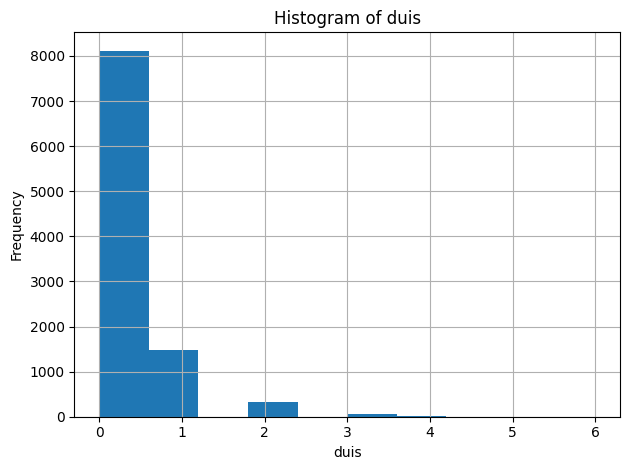

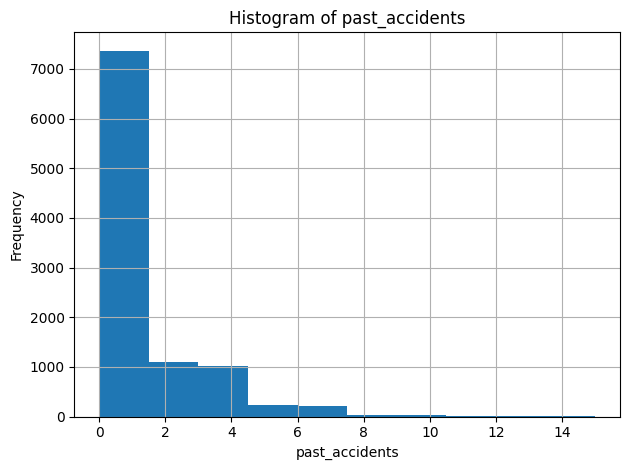

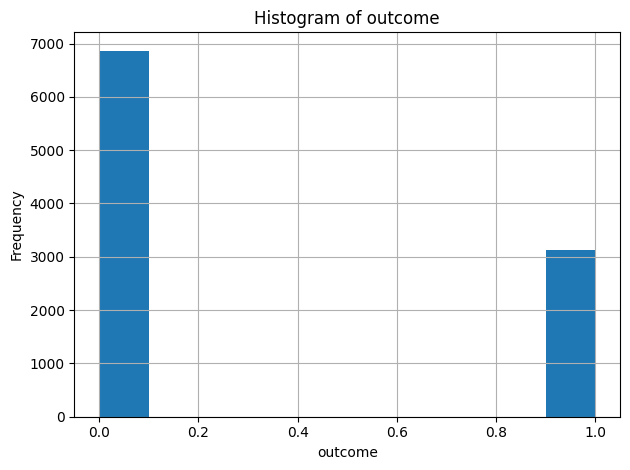

In [26]:
for col in num_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

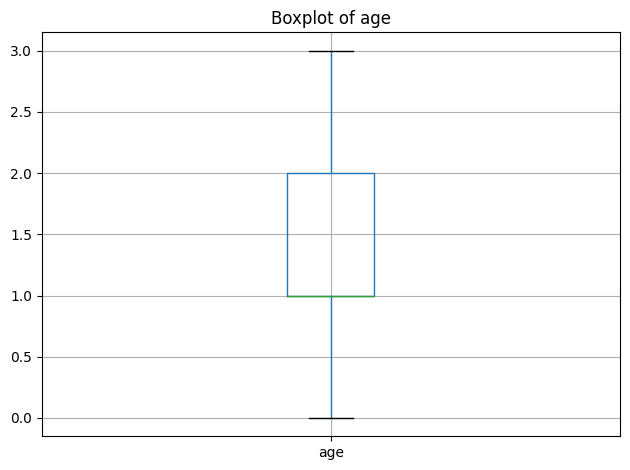

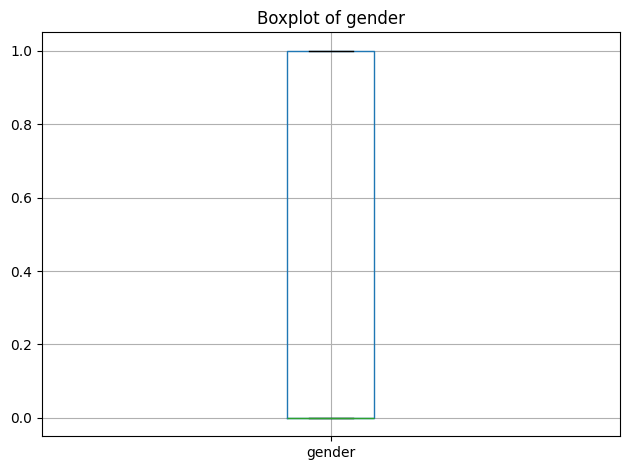

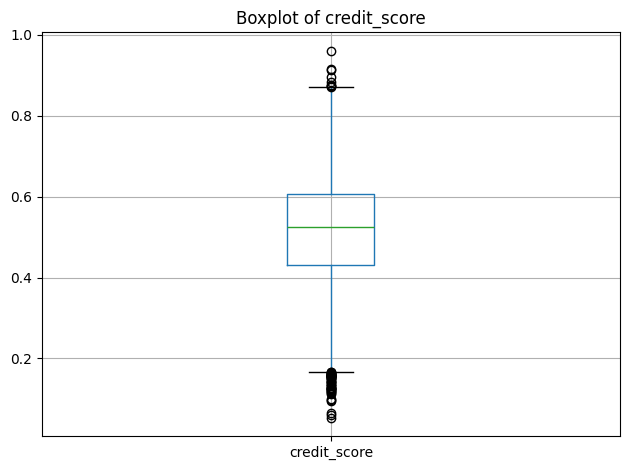

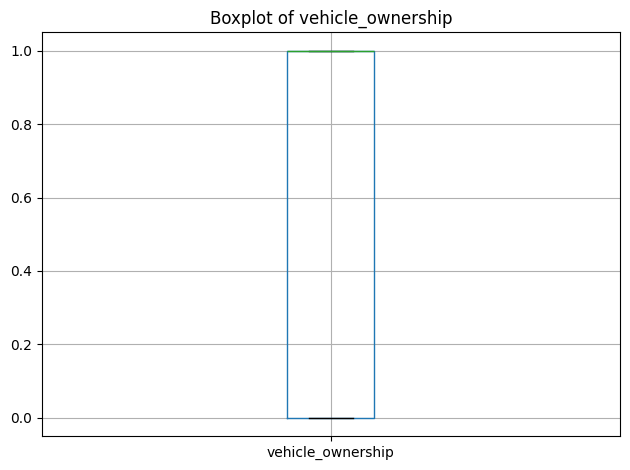

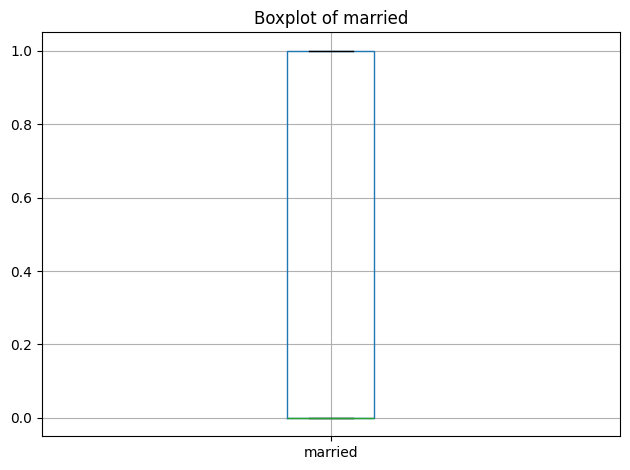

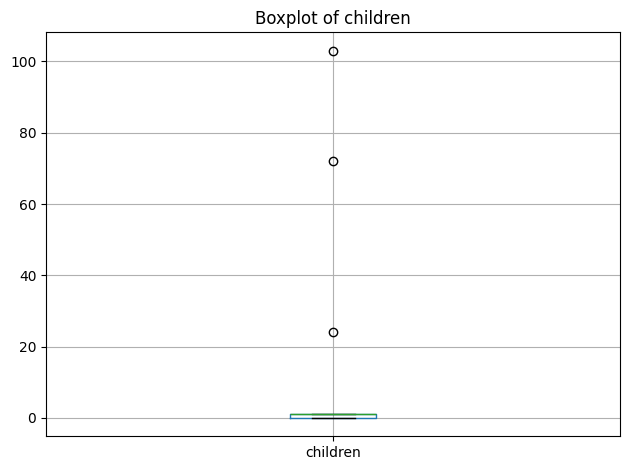

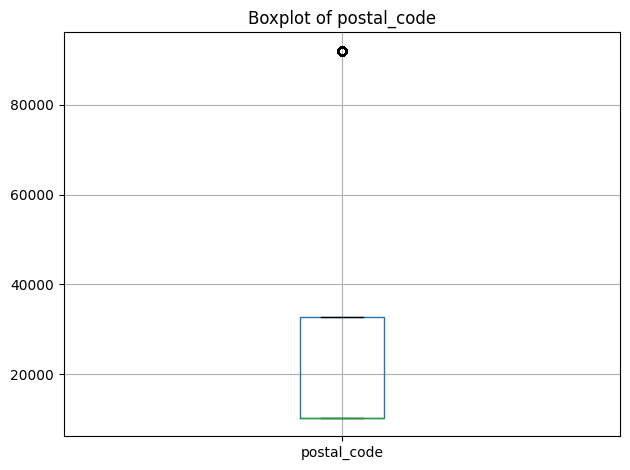

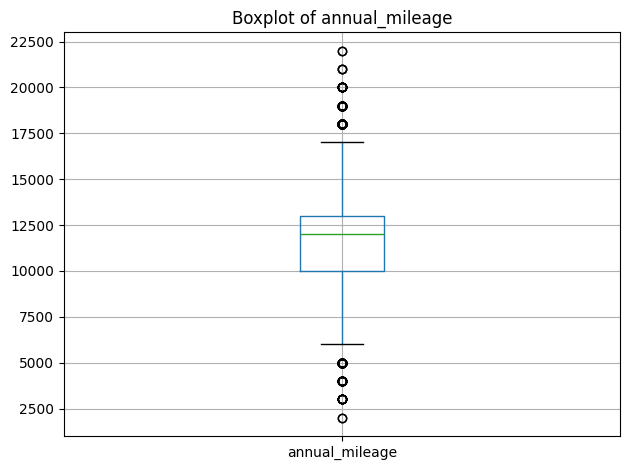

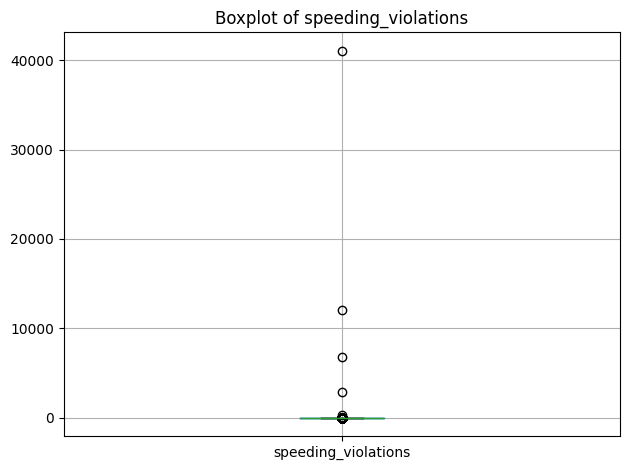

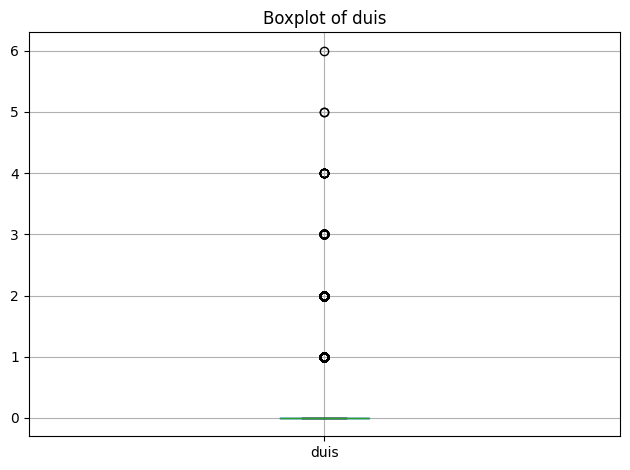

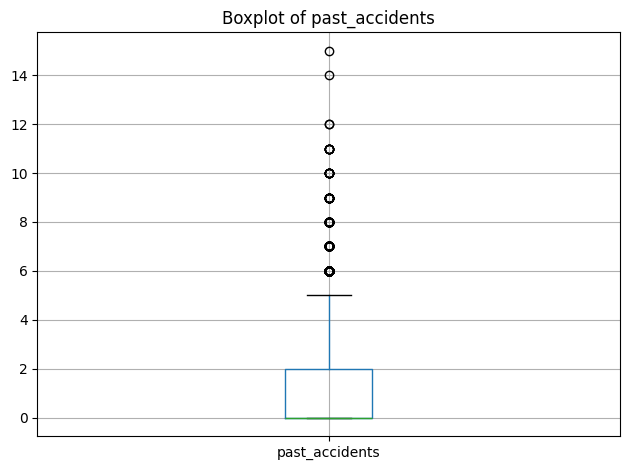

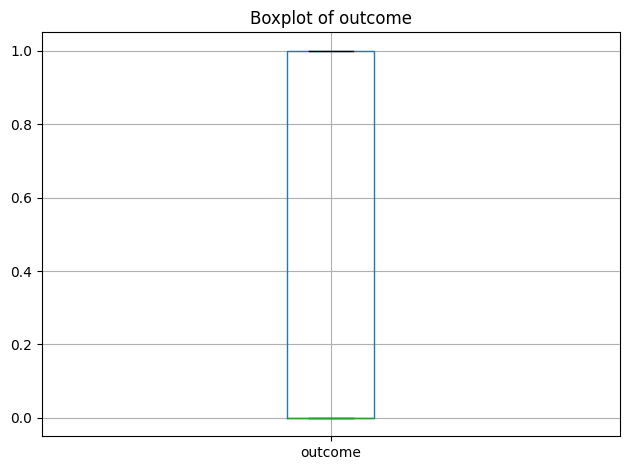

In [27]:
for col in num_cols:
    plt.figure()
    df.boxplot(column=[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [30]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    df[col] = df[col].mask(df[col] < low, low)
    df[col] = df[col].mask(df[col] > high, high)

print("Outliers replaced using IQR bounds.")
print(df[num_cols].describe())

Outliers replaced using IQR bounds.
                age        gender  credit_score  vehicle_ownership  \
count  10000.000000  10000.000000  10000.000000       10000.000000   
mean       1.489500      0.499000      0.516849           0.697000   
std        1.025278      0.500024      0.130275           0.459578   
min        0.000000      0.000000      0.167364           0.000000   
25%        1.000000      0.000000      0.431509           0.000000   
50%        1.000000      0.000000      0.525033           1.000000   
75%        2.000000      1.000000      0.607607           1.000000   
max        3.000000      1.000000      0.871752           1.000000   

            married      children   postal_code  annual_mileage  \
count  10000.000000  10000.000000  10000.000000    10000.000000   
mean       0.498300      0.689450  18628.146200    11718.950000   
std        0.500022      0.463956  14464.259248     2610.003278   
min        0.000000      0.000000  10238.000000     5500.000000  

In [33]:
from sklearn.preprocessing import LabelEncoder
bool_like = []
object_cols = df.select_dtypes(include=["object"]).columns

for col in object_cols:
    values = set(df[col].dropna().unique())
    if values == {"yes", "no"} or values == {"true", "false"}:
        bool_like.append(col)


for col in bool_like:
    df[col] = df[col].replace({"yes": 1, "no": 0, "true": 1, "false": 0})

encoder = LabelEncoder()

for col in object_cols:
    if col not in bool_like:
        df[col] = encoder.fit_transform(df[col].astype(str))

print("Categorical variables transformed into numerical form.")
print(df.head())

Categorical variables transformed into numerical form.
   age  gender  driving_experience  education  income  credit_score  \
0    3       0                   0          0       2      0.629027   
1    0       1                   0          1       1      0.357757   
2    0       0                   0          0       3      0.493146   
3    0       1                   0          2       3      0.206013   
4    1       1                   1          1       3      0.388366   

   vehicle_ownership  vehicle_year  married  children  postal_code  \
0                1.0             0      0.0       1.0      10238.0   
1                0.0             1      0.0       0.0      10238.0   
2                1.0             1      0.0       0.0      10238.0   
3                1.0             1      0.0       1.0      32765.0   
4                1.0             1      0.0       0.0      32765.0   

   annual_mileage  vehicle_type  speeding_violations  duis  past_accidents  \
0         12000.0  

In [34]:
from sklearn.preprocessing import StandardScaler
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

data_array = df[numeric_columns].to_numpy()


scaler = StandardScaler()
scaled_array = scaler.fit_transform(data_array)

normalized_df = pd.DataFrame(scaled_array, columns=numeric_columns)

print("Normalization completed.\n")
print(normalized_df.head())
print("\nSummary of normalized variables:\n")
print(normalized_df.describe())

Normalization completed.

        age    gender  driving_experience  education    income  credit_score  \
0  1.473333 -0.998002           -1.079662  -1.087026  0.434311      0.861131   
1 -1.452849  1.002002           -1.079662   0.025476 -0.557720     -1.221263   
2 -1.452849 -0.998002           -1.079662  -1.087026  1.426342     -0.181958   
3 -1.452849  1.002002           -1.079662   1.137979  1.426342     -2.386121   
4 -0.477455  1.002002           -0.069972   0.025476  1.426342     -0.986296   

   vehicle_ownership  vehicle_year   married  children  postal_code  \
0           0.659333     -1.515607 -0.996606  0.669386    -0.580090   
1          -1.516684      0.659802 -0.996606 -1.486099    -0.580090   
2           0.659333      0.659802 -0.996606 -1.486099    -0.580090   
3           0.659333      0.659802 -0.996606  0.669386     0.977413   
4           0.659333      0.659802 -0.996606 -1.486099     0.977413   

   annual_mileage  vehicle_type  speeding_violations  duis  past_a


=== Correlation matrix ===
                          age    gender  driving_experience  education  \
age                  1.000000  0.005929            0.707393   0.153339   
gender               0.005929  1.000000            0.007511   0.082831   
driving_experience   0.707393  0.007511            1.000000   0.094116   
education            0.153339  0.082831            0.094116   1.000000   
income               0.145340  0.012226            0.086181   0.079765   
credit_score         0.471453 -0.077688            0.327901   0.202743   
vehicle_ownership    0.272140  0.007385            0.202788   0.121432   
vehicle_year        -0.235390 -0.010674           -0.164915  -0.113857   
married              0.384468  0.008593            0.269726   0.105268   
children             0.381203 -0.002955            0.275466   0.074549   
postal_code          0.008759 -0.002075            0.006560   0.014328   
annual_mileage      -0.265771 -0.015254           -0.179905  -0.077148   
vehicle_ty

<Figure size 1000x800 with 0 Axes>

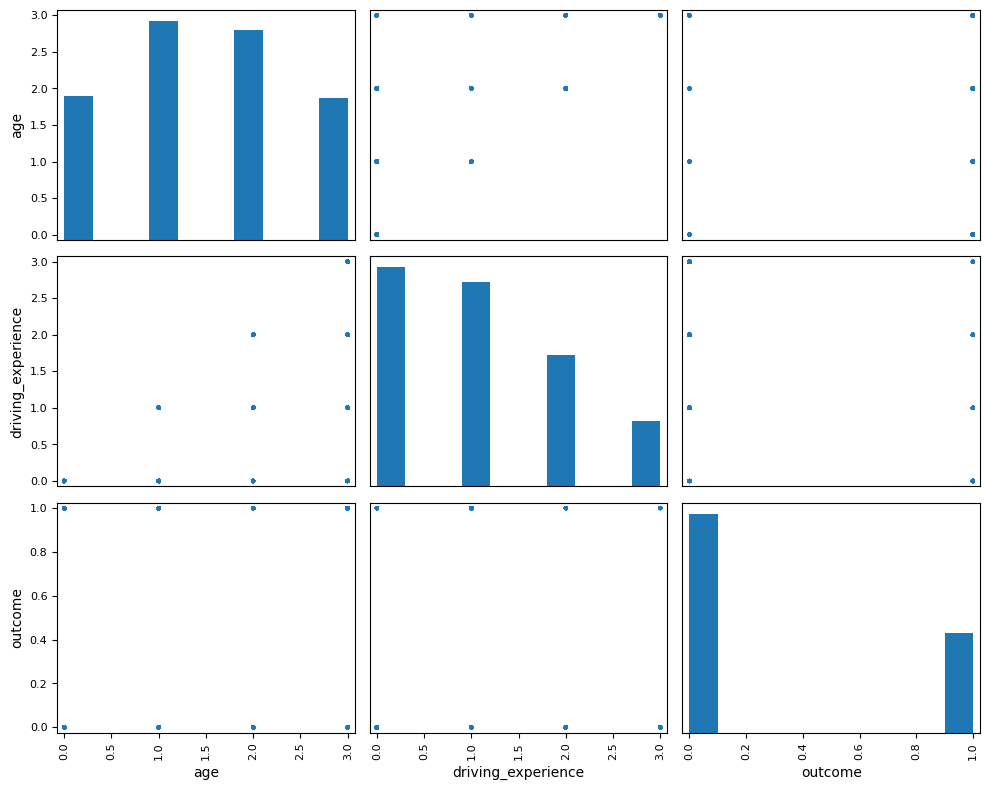

In [35]:
from pandas.plotting import scatter_matrix
num_cols = df.select_dtypes(include=["int64", "float64"]).columns


corr_matrix = df[num_cols].corr()

print("\n=== Correlation matrix ===")
print(corr_matrix)


target = "outcome"

if target in num_cols:
    print(f"\n=== Correlation of each variable with '{target}' ===")
    print(corr_matrix[target].sort_values(ascending=False))
else:
    print(f"Target '{target}' not found in numerical columns.")


sorted_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
sorted_corr = sorted_corr[sorted_corr < 1]

print("\n=== Strongest correlations between input variables ===")
print(sorted_corr.head(10))


selected = sorted_corr.head(3).index.get_level_values(0).tolist()
selected = list(dict.fromkeys(selected))


if target not in selected and target in df.columns:
    selected.append(target)

selected = [col for col in selected if col in num_cols]

print("\nVariables used for scatter matrix:", selected)


plt.figure(figsize=(10, 8))
scatter_matrix(df[selected], figsize=(10, 8), diagonal='hist')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["outcome"]).to_numpy()
y = df["outcome"].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)


total = len(df)
train_size = len(X_train)
test_size = len(X_test)

print("Training set size:", train_size, "elements")
print("Test set size:", test_size, "elements")
print("\nTraining set proportion:", train_size / total)
print("Test set proportion:", test_size / total)

Training set size: 8000 elements
Test set size: 2000 elements

Training set proportion: 0.8
Test set proportion: 0.2


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = df.drop(columns=["outcome"]).to_numpy()
y = df["outcome"].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=7
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Training complete.")
print("Model coefficients:\n", model.coef_)
print("Model intercept:\n", model.intercept_)

Training complete.
Model coefficients:
 [[ 5.10124170e-03  8.81538816e-01 -1.85288686e+00 -3.44401087e-02
  -1.76739655e-02 -4.61147885e-01 -1.69654700e+00  1.64232922e+00
  -4.14539727e-01 -1.90922855e-01  3.33662663e-05  6.43836831e-05
  -4.00991550e-02  9.78434718e-02  0.00000000e+00 -1.40402863e-01]]
Model intercept:
 [-0.85836899]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
X = df.drop(columns=["outcome"]).to_numpy()
y = df["outcome"].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=10
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


pred = model.predict(X_test)


for i in range(len(pred)):
    print(f"Predicted: {pred[i]}   Actual: {y_test[i]}")


acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("\nAccuracy:", acc)
print("\nConfusion matrix:\n", cm)
print("\nPrecision:", prec)
print("Recall:", rec)
print("F1 score:", f1)

Predicted: 1.0   Actual: 1.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 1.0   Actual: 0.0
Predicted: 1.0   Actual: 1.0
Predicted: 1.0   Actual: 0.0
Predicted: 1.0   Actual: 1.0
Predicted: 0.0   Actual: 1.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 1.0   Actual: 1.0
Predicted: 1.0   Actual: 1.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 1.0   Actual: 0.0
Predicted: 1.0   Actual: 0.0
Predicted: 1.0   Actual: 0.0
Predicted: 0.0   Actual: 1.0
Predicted: 1.0   Actual: 1.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 1.0   Actual: 0.0
Predicted: 1.0   Actual: 1.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 1.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 1.0   Actual: 1.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0   Actual: 0.0
Predicted: 1.0   Actual: 1.0
Predicted: 0.0   Actual: 0.0
Predicted: 0.0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np
X = df.drop(columns=["outcome"]).to_numpy()
y = df["outcome"].to_numpy()


k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=12)


model = LogisticRegression(max_iter=1000)


scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

print("Cross-validation scores for each fold:")
for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score}")

print("\nMean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-validation scores for each fold:
Fold 1: 0.8405
Fold 2: 0.832
Fold 3: 0.849
Fold 4: 0.849
Fold 5: 0.841

Mean accuracy: 0.8423
Standard deviation: 0.006337191807101947


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
X = df.drop(columns=["outcome"]).to_numpy()
y = df["outcome"].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=15
)

kf = KFold(n_splits=5, shuffle=True, random_state=15)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Perceptron": Perceptron(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")
    print(f"\n{name}")
    print("Cross-validation scores:", scores)
    print("Mean accuracy:", scores.mean())
    print("Std deviation:", scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Logistic Regression
Cross-validation scores: [0.8435 0.8515 0.8395 0.8425 0.8305]
Mean accuracy: 0.8414999999999999
Std deviation: 0.006782329983125275

Perceptron
Cross-validation scores: [0.2975 0.3155 0.677  0.4355 0.672 ]
Mean accuracy: 0.4795
Std deviation: 0.1661436125765899

KNN (k=5)
Cross-validation scores: [0.795  0.802  0.7925 0.807  0.785 ]
Mean accuracy: 0.7963
Std deviation: 0.00762627038597506

Random Forest
Cross-validation scores: [0.841  0.8405 0.833  0.829  0.826 ]
Mean accuracy: 0.8338999999999999
Std deviation: 0.0060199667773169815


In [56]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
final_model = LogisticRegression(max_iter=200)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


saved_file = "trained_model.pkl"
saved_scaler = "scaler.pkl"

with open(saved_file, "wb") as f:
    pickle.dump(final_model, f)

with open(saved_scaler, "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully.")

with open(saved_file, "rb") as f:
    loaded_model = pickle.load(f)

with open(saved_scaler, "rb") as f:
    loaded_scaler = pickle.load(f)

print("Model and scaler loaded successfully.")



Accuracy : 0.8405
Confusion matrix:
 [[1239  134]
 [ 185  442]]
Model and scaler saved successfully.
Model and scaler loaded successfully.
